=== Building Rust binary in release mode ===
Cargo build completed successfully.

Running for table_type=naive with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--op-ratio', '0.005', '--txn-count', '40', '--delta-count', '6', '--warehouse-count', '10', '--table-type', 'naive']
-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 232323223
-----------------------------------------------------------------------

Update ratio: 0.005
Analytical ratio: 0.4
Number of transactions (max Timestamp value): 40
Number of delta_scan transactions: 6

-----------------------------------------------------------------------

txs:
idx:   0, tx_id:   0, tx_ts:   0, tx_type:   InitLoad, Insert count: 300000
idx:   1, tx_id:   1, tx_ts:   1, tx_type:     MarkTs, Mark Ts: 1
idx:   2, tx_id:   2, tx_ts:   2, tx_type:     Update, Update count: 1500
idx:   3, tx_id:   3, tx_ts:   3, tx_type:     Update, Update count: 1500
idx:   4, tx_id

,idx,tx_id,tx_type,repair_type,table_type,duration_ms,count,read_ts,from_ts,to_ts
0,0,0,InitLoad,No Repair,naive,71.676442,300000.0,NaN,NaN,NaN
1,0,0,InitLoad,Read Repair,naive,69.478357,300000.0,NaN,NaN,NaN
2,0,0,InitLoad,Write Repair,naive,69.087214,300000.0,NaN,NaN,NaN
3,1,1,MarkTs,No Repair,naive,116.626905,NaN,1.0,NaN,NaN
4,1,1,MarkTs,Read Repair,naive,117.201308,NaN,1.0,NaN,NaN
5,1,1,MarkTs,Write Repair,naive,117.237928,NaN,1.0,NaN,NaN
6,2,2,Update,No Repair,naive,0.645904,1500.0,NaN,NaN,NaN
7,2,2,Update,Read Repair,naive,0.643429,1500.0,NaN,NaN,NaN
8,2,2,Update,Write Repair,naive,0.651275,1500.0,NaN,NaN,NaN
9,3,3,Update,No Repair,naive,0.603716,1500.0,NaN,NaN,NaN


x labels: ['0\nInitLoad\ncnt: 300K', '1\nMarkTs\nts: 1', '2\nUpdate\ncnt: 1.5K', '3\nUpdate\ncnt: 1.5K', '4\nUpdate\ncnt: 1.5K', '5\nUpdate\ncnt: 1.5K', '6\nProbe\ncnt: 1.5K, ts: 1', '7\nUpdate\ncnt: 1.5K', '8\nUpdate\ncnt: 1.5K', '9\nProbe\ncnt: 1.5K, ts: 1', '10\nUpdate\ncnt: 1.5K', '11\nUpdate\ncnt: 1.5K', '12\nUpdate\ncnt: 1.5K', '13\nMarkTs\nts: 13', '14\nUpdate\ncnt: 1.5K', '15\nMarkTs\nts: 15', '16\nUpdate\ncnt: 1.5K', '17\nMarkTs\nts: 17', '18\nUpdate\ncnt: 1.5K', '19\nProbe\ncnt: 1.5K, ts: 1', '20\nUpdate\ncnt: 1.5K', '21\nUpdate\ncnt: 1.5K', '22\nUpdate\ncnt: 1.5K', '23\nUpdate\ncnt: 1.5K', '24\nUpdate\ncnt: 1.5K', '25\nUpdate\ncnt: 1.5K', '26\nMarkTs\nts: 26', '27\nUpdate\ncnt: 1.5K', '28\nUpdate\ncnt: 1.5K', '29\nUpdate\ncnt: 1.5K', '30\nMarkTs\nts: 30', '31\nUpdate\ncnt: 1.5K', '32\nUpdate\ncnt: 1.5K', '33\nUpdate\ncnt: 1.5K', '34\nUpdate\ncnt: 1.5K', '35\nUpdate\ncnt: 1.5K', '36\nMarkTs\nts: 36', '37\nUpdate\ncnt: 1.5K', '38\nMarkTs\nts: 38', '39\nScan\nts: 38', '40\nScan

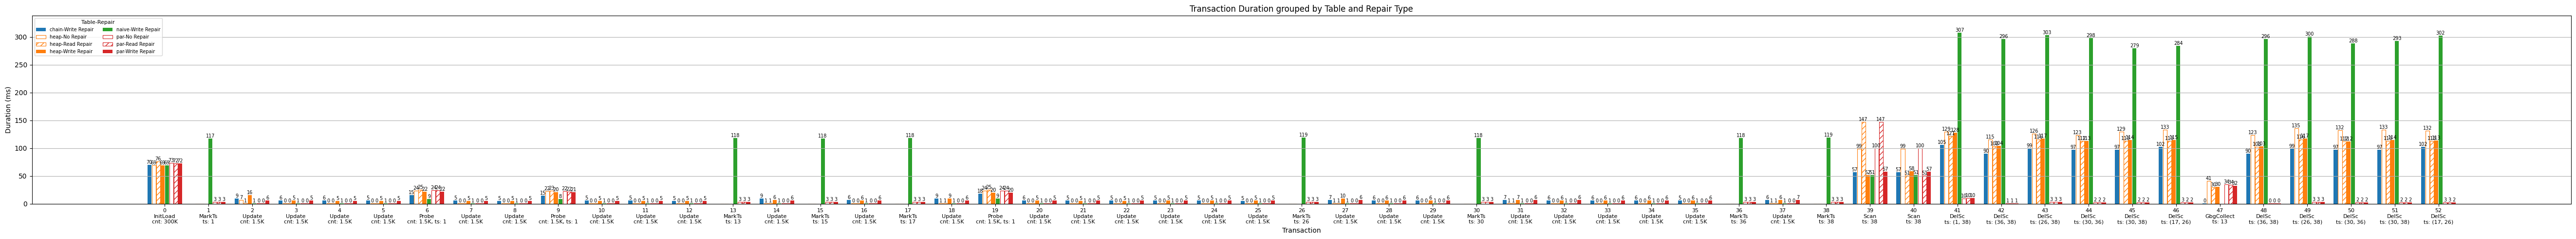

In [ ]:
import subprocess
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import re

# ----------------------------------------
# Build the Rust binary
# ----------------------------------------
print("=== Building Rust binary in release mode ===")
build_cmd = ["cargo", "build", "--release", "--bin", "htap_wkld"]
result = subprocess.run(build_cmd, capture_output=True, text=True)
if result.returncode != 0:
    print("[ERROR] cargo build failed.\n", result.stderr)
    raise SystemExit(1)
print("Cargo build completed successfully.\n")


BASE_ARGS = [
    "--op-ratio", "0.005",  # update ratio, % of base table
    "--txn-count", "40",  
    "--scan-count", "6",  # delta scan count
    "--warehouse-count", "35" # linear to base table size
]
REPEAT=1
BIN = Path("../../../target/release/htap_wkld")
TABLE_TYPES = [ "naive", "heap", "par", "chain"]

def prepare_bar_style(repair_type, table_type, color_map, repair_hatches):
    if repair_type == "Write Repair":
        return {
            'facecolor': color_map[table_type],
            'edgecolor': color_map[table_type],
            'hatch': '',
            'linewidth': 0
        }
    else:
        return {
            'facecolor': 'white',
            'edgecolor': color_map[table_type],
            'hatch': repair_hatches.get(repair_type, ''),
            'linewidth': 0.8
        }
def draw_bar_labels(ax, x_positions, heights, font_size=7):
    for x, y in zip(x_positions, heights):
        if y > 0:  
            ax.text(
                x, 
                y, 
                f"{y:.0f}", 
                ha='center', 
                va='bottom', 
                fontsize=font_size
            )
from bench_script_functions import prepare_plot_data
def plot_all(df):
    color_map, repair_hatches, repair_types, table_types, unique_idx, x_labels, _ = prepare_plot_data(df)

    fig, ax = plt.subplots(figsize=(max(8, len(unique_idx) * 1.0), 5))

    groups = []
    for table_type in table_types:
        if table_type in ["chain", "naive"]:
            groups.append((table_type, "Write Repair"))
        else:
            for repair_type in repair_types:
                groups.append((table_type, repair_type))

    num_bars_per_group = len(groups)
    group_width = 0.8
    bar_width = group_width / num_bars_per_group

    idx_to_pos = {idx: pos for pos, idx in enumerate(unique_idx)}

    duration_max = 0.0
    for i, (table_type, repair_type) in enumerate(groups):
        if table_type in ["chain", "naive"] and repair_type != "Write Repair":
            continue

        df_group = df[(df['table_type'] == table_type) & (df['repair_type'] == repair_type)]

        x_positions = []
        durations = []

        for idx in unique_idx:
            x_pos = idx_to_pos[idx] + (i - num_bars_per_group/2) * bar_width + bar_width/2
            df_row = df_group[df_group['idx'] == idx]
            duration = df_row['duration_ms'].values[0] if not df_row.empty else 0
            x_positions.append(x_pos)
            durations.append(duration)

        style = prepare_bar_style(repair_type, table_type, color_map, repair_hatches)

        ax.bar(
            x_positions,
            durations,
            width=bar_width * 0.9,
            label=f"{table_type}-{repair_type}",
            **style
        )
        duration_max = max(duration_max, max(durations))
        draw_bar_labels(ax, x_positions, durations)

  
    print(f"duration_max: {duration_max}")
    max_y = duration_max * 1.1
    ax.set_ylim(0, max_y)

    ax.set_xticks(range(len(unique_idx)))
    ax.set_xticklabels(x_labels, rotation=0, fontsize=8, ha='center')

    ax.set_xlabel('Transaction')
    ax.set_ylabel('Duration (ms)')
    ax.set_title(f'Transaction Duration grouped by Table and Repair Type')

    plt.grid(True, axis='y')

    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), title="Table-Repair", fontsize=7, title_fontsize=8, ncol=2)

    plt.tight_layout()
    plt.show()
from bench_script_functions import run_and_collect
df = run_and_collect(BIN, TABLE_TYPES, BASE_ARGS, REPEAT)
# Display the resulting DataFrame
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
display(df)
plot_all(df)



# DELTA TRADEOFF

In [ ]:
import subprocess
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import re

BASE_ARGS = [
    "--txn-count", "16",
    "--scan-count", "6",
]
REPEAT=1
BIN = Path("../../../target/release/htap_wkld")
TABLE_TYPES = ["naive", "heap"]
UPDATE_RATIOS = ["0.01", "0.05", "0.1", "0.2"]

from bench_script_functions import run_and_collect, prepare_plot_data


def get_avg(df):
    color_map, repair_hatches, repair_types, table_types, _, _, _ = prepare_plot_data(df)
    tx_type_groups = ["DeltaScan"]
    groups = []
    for table_type in table_types:
        if table_type in ['naive', 'chain']:
            groups.append((table_type, 'Write Repair'))
        else:
            for repair_type in repair_types:
                groups.append((table_type, repair_type))
    
    durations = []
    for i, (table_type, repair_type) in enumerate(groups):
        if table_type in ["chain", "naive"] and repair_type != "Write Repair":
            continue

        df_group = df[(df['table_type'] == table_type) & (df['repair_type'] == repair_type)]
        
        # DeltaScan only average
        scan_vals = df_group[df_group['tx_type'] == "DeltaScan"]['duration_ms'].values
        avg_delta_scan = scan_vals.mean() if len(scan_vals) > 0 else 0
        durations.append((table_type, repair_type, avg_delta_scan)) # table_type, repair_type, avg_duration

    return durations

# get ratio over base_type
def get_ratio(avg, base_type, update_ratio):
    result = []
    ratio_col_name = f'ratio_over_{base_type}'
    base = None
    for (table_type, repair_type, avg_dur) in avg:
        if table_type in [base_type]:
            base = avg_dur
    
    for (table_type, repair_type, avg_dur) in avg:
        if table_type not in [base_type]:
            result.append({"update_ratio": update_ratio, "table_type": table_type, "repair_type": repair_type, ratio_col_name: avg_dur / base})

    df_res = pd.DataFrame(result)
    return df_res

df_ratio = pd.DataFrame()
for update_ratio in UPDATE_RATIOS:
    NEW_ARGS = BASE_ARGS.copy()
    NEW_ARGS += ["--op-ratio", update_ratio]
    
    df = run_and_collect(BIN, TABLE_TYPES, NEW_ARGS, REPEAT)

    # Display the resulting DataFrame
    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    pd.set_option('display.max_colwidth', None)
    # display(df)
    df_avg = get_avg(df)
    ratio = get_ratio(df_avg, 'naive', update_ratio)
    df_ratio = pd.concat([df_ratio, ratio], ignore_index=True)
df_ratio['idx'] = range(len(df_ratio))

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
def draw_plot(df):

    # Optional: combine table_type and repair_type into a single label
    df["config"] = df["table_type"] + " | " + df["repair_type"]

    # Plot grouped barplot
    plt.figure(figsize=(8, 6))
    sns.barplot(data=df, x="update_ratio", y="ratio_over_naive", hue="config")

    plt.ylabel("Ratio: Naive over Heap")
    plt.xlabel("Update Ratio")
    plt.title("Grouped Ratio over Naive by Update Ratio and Config")
    plt.legend(title="Table Type | Repair Type", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

draw_plot(df_ratio)


# Space Statistics

In [ ]:
import subprocess
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import re

# ----------------------------------------
# Build the Rust binary
# ----------------------------------------
print("=== Building Rust binary in release mode ===")
build_cmd = ["cargo", "build", "--release", "--bin", "htap_wkld"]
result = subprocess.run(build_cmd, capture_output=True, text=True)
if result.returncode != 0:
    print("[ERROR] cargo build failed.\n", result.stderr)
    raise SystemExit(1)
print("Cargo build completed successfully.\n")


BASE_ARGS = [
    "--op-ratio", "0.01",  # update ratio, % of base table
    "--txn-count", "25",  
    "--scan-count", "6",  # delta scan count
    "--warehouse-count", "33" # linear to base table size
]
REPEAT=1
BIN = Path("../../../target/release/htap_wkld")
TABLE_TYPES = [ "naive", "heap", "par", "chain"]

from bench_script_functions import run_and_collect

df = run_and_collect(BIN, TABLE_TYPES, BASE_ARGS, REPEAT)
# Display the resulting DataFrame
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
display(df)

def plot_nested_space(df):
    for col in ["total_space", "all_versions_space", "valid_space"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df["all_versions_ratio"] = df["all_versions_space"] / df["total_space"]
    df["valid_ratio"] = df["valid_space"] / df["total_space"]

    fig, ax = plt.subplots(figsize=(8,6))
    bar_width = 0.5

    ax.bar(df["table_type"], df["total_space"], 
           color="lightgray", width=bar_width, label="total_space")
    ax.bar(df["table_type"], df["all_versions_space"], 
           color="skyblue", width=bar_width*0.7, label="all_versions_space")
    ax.bar(df["table_type"], df["valid_space"], 
           color="dodgerblue", width=bar_width*0.4, label="valid_space(newest version)")

    for i, row in df.iterrows():
        total_mb = row["total_space"] / 1e6
        all_versions_mb = row["all_versions_space"] / 1e6
        valid_mb = row["valid_space"] / 1e6

        ax.text(i - 0.2, row["total_space"] * 1.02, f"{total_mb:.1f} MB", 
                ha="center", va="center", fontsize=8, color="black")
        ax.text(i - 0.2, row["all_versions_space"] * 1.02, f"{all_versions_mb:.1f} MB", 
                ha="center", va="center", fontsize=8, color="black")
        ax.text(i - 0.2, row["valid_space"] * 1.02, f"{valid_mb:.1f} MB", 
                ha="center", va="center", fontsize=8, color="black")

        ax.text(i + 0.2, row["all_versions_space"] * 1.02,
                f"{row['all_versions_ratio']:.1%}", 
                ha="center", va="bottom", fontsize=9, color="blue")
        ax.text(i + 0.2, row["valid_space"] * 1.02,
                f"{row['valid_ratio']:.1%}", 
                ha="center", va="bottom", fontsize=9, color="darkblue")

    ax.set_ylabel("Space (bytes)")
    max_value = df[["total_space", "all_versions_space", "valid_space"]].values.max()
    ax.set_ylim(0, max_value * 1.15)
    ax.set_title("Nested Bar Chart with Ratios and Sizes (MB)")
    ax.legend()
    plt.tight_layout()
    plt.show()


plot_nested_space(df)



# Stacked Bar Chart -- analytical

=== Building Rust binary in release mode ===
Cargo build completed successfully.

Running for table_type=naive with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--op-ratio', '0.005', '--txn-count', '40', '--warehouse-count', '10', '--analytical-ratio', '0.7', '--scan-count', '6', '--table-type', 'naive']
-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 232323223
-----------------------------------------------------------------------

Update ratio: 0.005
Analytical ratio: 0.7
Number of transactions (max Timestamp value): 40
Number of each scan transactions: 6

-----------------------------------------------------------------------

txs:
idx:   0, tx_id:   0, tx_ts:   0, tx_type:   InitLoad, Insert count: 300000
idx:   1, tx_id:   1, tx_ts:   1, tx_type:     MarkTs, Mark Ts: 1
idx:   2, tx_id:   2, tx_ts:   2, tx_type:     MarkTs, Mark Ts: 2
idx:   3, tx_id:   3, tx_ts:   3, tx_type:      Probe, Probe count: 15

,table_type,repair_type,tx_type,duration_ms
0,chain,Write Repair,DelSc,101.696336
1,chain,Write Repair,FirstScan,58.116597
2,chain,Write Repair,GbgCollect,0.097442
3,chain,Write Repair,InitLoad,69.098064
4,chain,Write Repair,MarkTs,0.000000
5,chain,Write Repair,Probe,15.116513
6,chain,Write Repair,Scan,58.122379
7,chain,Write Repair,Update,6.513048
8,heap,No Repair,DelSc,113.022370
9,heap,No Repair,FirstScan,97.144888


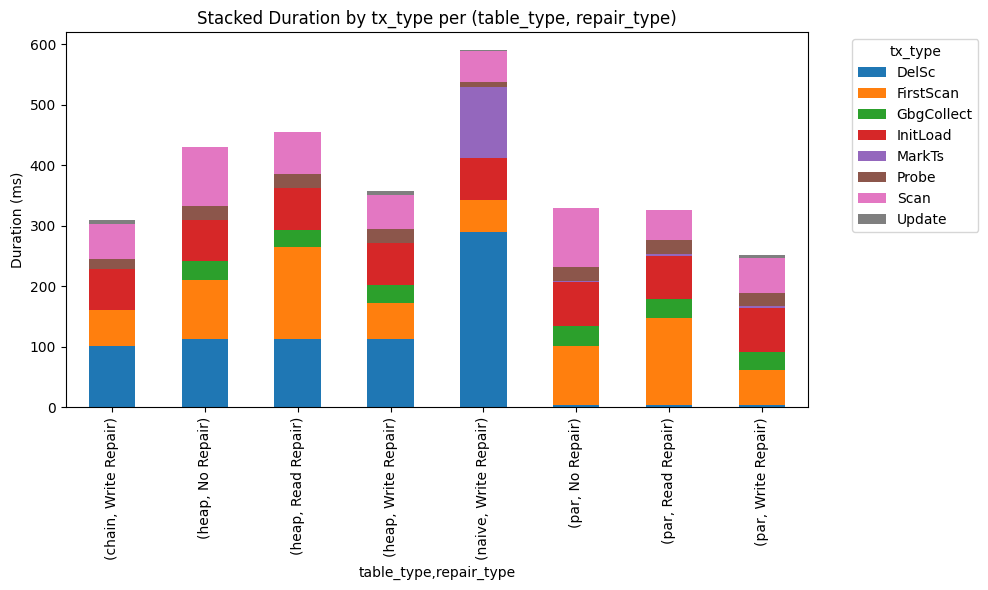

In [ ]:
import subprocess
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import re

TITLE = "Analytical Heavy"

# ----------------------------------------
# Build the Rust binary
# ----------------------------------------
print("=== Building Rust binary in release mode ===")
build_cmd = ["cargo", "build", "--release", "--bin", "htap_wkld"]
result = subprocess.run(build_cmd, capture_output=True, text=True)
if result.returncode != 0:
    print("[ERROR] cargo build failed.\n", result.stderr)
    raise SystemExit(1)
print("Cargo build completed successfully.\n")


BASE_ARGS = [
    "--op-ratio", "0.005",  # update ratio, % of base table
    "--txn-count", "40",  
    "--warehouse-count", "35" # linear to base table size
]
REPEAT=1
BIN = Path("../../../target/release/htap_wkld")
TABLE_TYPES = [ "naive", "heap", "par", "chain"]

from bench_script_functions import run_and_collect, prepare_plot_data

def plot_all2(df):
    color_map, repair_hatches, repair_types, table_types, unique_idx, x_labels, dict_labels = prepare_plot_data(df)

    groups = []
    for table_type in table_types:
        if table_type in ["chain", "naive"]:
            groups.append((table_type, "Write Repair"))
        else:
            for repair_type in repair_types:
                groups.append((table_type, repair_type))

    print(groups)
    type_and_durations = []
    for i, (table_type, repair_type) in enumerate(groups):
        if table_type in ["chain", "naive"] and repair_type != "Write Repair":
            continue

        df_group = df[(df['table_type'] == table_type) & (df['repair_type'] == repair_type)]

        scan_count = 0

        for idx in unique_idx:
            df_row = df_group[df_group['idx'] == idx]
            duration = df_row['duration_ms'].values[0] if not df_row.empty else 0
            label = dict_labels[idx]
            cur_tx_type = label['tx_type']
            if cur_tx_type == "Scan":
                scan_count += 1
                if scan_count == 1:
                    cur_tx_type = "FirstScan"
            # line = {"table_type": table_type, "repair_type": repair_type, "duration_ms":duration, "tx_type": cur_tx_type, "idx": label["idx"], "optional": label["optional"] }
            line = {"table_type": table_type, "repair_type": repair_type, "duration_ms":duration, "tx_type": cur_tx_type, "idx": label["idx"], "optional": label["optional"] }
            type_and_durations.append(line)
    # print(type_and_durations)
    df = pd.DataFrame(type_and_durations)

    result = (
        df.groupby(["table_type", "repair_type", "tx_type"], as_index=False)
        .agg(duration_ms=("duration_ms", lambda x: x.sum() if x.name[2] == "Update" or x.name[2] == "Probe" else x.mean()))
    )
    display(result)

    def draw_stack_bar(df):
        pivot_df = df.pivot_table(
            index=["table_type", "repair_type"],
            columns="tx_type",
            values="duration_ms",
            aggfunc="sum",
            fill_value=0
        )

        # stacked bar chart
        ax = pivot_df.plot(
            kind="bar",
            stacked=True,
            figsize=(10, 6)
        )

        plt.ylabel("Duration (ms)")
        plt.title(f"Stacked Duration ({TITLE})")
        plt.legend(title="tx_type", bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.tight_layout()
        plt.show()
    draw_stack_bar(result)
added_args = [
    "--analytical-ratio", "0.7",
    "--scan-count", "6"
]

df = run_and_collect(BIN, TABLE_TYPES, BASE_ARGS + added_args, REPEAT)
# Display the resulting DataFrame
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
plot_all2(df)




# Delta Scan -- transactional

=== Building Rust binary in release mode ===
Cargo build completed successfully.

Running for table_type=naive with 1 repeats...
   - Trail 1/1
['../../../target/release/htap_wkld', '--op-ratio', '0.005', '--txn-count', '40', '--warehouse-count', '10', '--analytical-ratio', '0.2', '--scan-count', '2', '--table-type', 'naive']
-----------------------------------------------------------------------
Hash table type: Naive
Rng seed: 232323223
-----------------------------------------------------------------------

Update ratio: 0.005
Analytical ratio: 0.2
Number of transactions (max Timestamp value): 40
Number of each scan transactions: 2

-----------------------------------------------------------------------

txs:
idx:   0, tx_id:   0, tx_ts:   0, tx_type:   InitLoad, Insert count: 300000
idx:   1, tx_id:   1, tx_ts:   1, tx_type:     MarkTs, Mark Ts: 1
idx:   2, tx_id:   2, tx_ts:   2, tx_type:     Update, Update count: 1500
idx:   3, tx_id:   3, tx_ts:   3, tx_type:     Update, Update 

,table_type,repair_type,tx_type,duration_ms
0,chain,Write Repair,DelSc,102.024737
1,chain,Write Repair,FirstScan,57.037636
2,chain,Write Repair,GbgCollect,0.210083
3,chain,Write Repair,InitLoad,69.175489
4,chain,Write Repair,MarkTs,0.000000
5,chain,Write Repair,Probe,16.107097
6,chain,Write Repair,Scan,56.492565
7,chain,Write Repair,Update,5.415365
8,heap,No Repair,DelSc,118.126151
9,heap,No Repair,FirstScan,107.074099


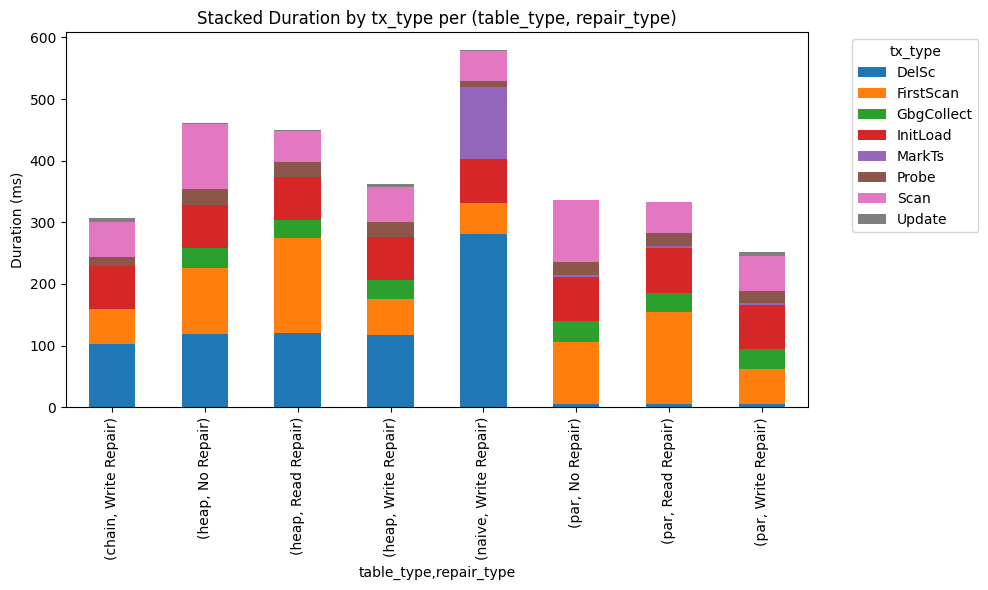

In [ ]:
import subprocess
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import re

TITLE = "Transactional Heavy"

# ----------------------------------------
# Build the Rust binary
# ----------------------------------------
print("=== Building Rust binary in release mode ===")
build_cmd = ["cargo", "build", "--release", "--bin", "htap_wkld"]
result = subprocess.run(build_cmd, capture_output=True, text=True)
if result.returncode != 0:
    print("[ERROR] cargo build failed.\n", result.stderr)
    raise SystemExit(1)
print("Cargo build completed successfully.\n")


BASE_ARGS = [
    "--op-ratio", "0.005",  # update ratio, % of base table
    "--txn-count", "40",  
    "--warehouse-count", "35" # linear to base table size
]
REPEAT=1
BIN = Path("../../../target/release/htap_wkld")
TABLE_TYPES = [ "naive", "heap", "par", "chain"]

from bench_script_functions import run_and_collect, prepare_plot_data

def plot_all2(df):
    color_map, repair_hatches, repair_types, table_types, unique_idx, x_labels, dict_labels = prepare_plot_data(df)

    groups = []
    for table_type in table_types:
        if table_type in ["chain", "naive"]:
            groups.append((table_type, "Write Repair"))
        else:
            for repair_type in repair_types:
                groups.append((table_type, repair_type))

    print(groups)
    type_and_durations = []
    for i, (table_type, repair_type) in enumerate(groups):
        if table_type in ["chain", "naive"] and repair_type != "Write Repair":
            continue

        df_group = df[(df['table_type'] == table_type) & (df['repair_type'] == repair_type)]

        scan_count = 0

        for idx in unique_idx:
            df_row = df_group[df_group['idx'] == idx]
            duration = df_row['duration_ms'].values[0] if not df_row.empty else 0
            label = dict_labels[idx]
            cur_tx_type = label['tx_type']
            if cur_tx_type == "Scan":
                scan_count += 1
                if scan_count == 1:
                    cur_tx_type = "FirstScan"
            # line = {"table_type": table_type, "repair_type": repair_type, "duration_ms":duration, "tx_type": cur_tx_type, "idx": label["idx"], "optional": label["optional"] }
            line = {"table_type": table_type, "repair_type": repair_type, "duration_ms":duration, "tx_type": cur_tx_type, "idx": label["idx"], "optional": label["optional"] }
            type_and_durations.append(line)
    # print(type_and_durations)
    df = pd.DataFrame(type_and_durations)

    result = (
        df.groupby(["table_type", "repair_type", "tx_type"], as_index=False)
        .agg(duration_ms=("duration_ms", lambda x: x.sum() if x.name[2] == "Update" or x.name[2] == "Probe" else x.mean()))
    )
    display(result)

    def draw_stack_bar(df):
        pivot_df = df.pivot_table(
            index=["table_type", "repair_type"],
            columns="tx_type",
            values="duration_ms",
            aggfunc="sum",
            fill_value=0
        )

        # stacked bar chart
        ax = pivot_df.plot(
            kind="bar",
            stacked=True,
            figsize=(10, 6)
        )

        plt.ylabel("Duration (ms)")
        plt.title(f"Stacked Duration ({TITLE})")
        plt.legend(title="tx_type", bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.tight_layout()
        plt.show()
    draw_stack_bar(result)
added_args = [
    "--analytical-ratio", "0.2",
    "--scan-count", "2"
]

df = run_and_collect(BIN, TABLE_TYPES, BASE_ARGS + added_args, REPEAT)
# Display the resulting DataFrame
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
plot_all2(df)


